In [1]:
from rqvae import RQVAE, RQVAELoss
from pathlib import Path
import torch
import torch.nn as nn
import torch.functional as F
from torch.utils import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, label_ranking_average_precision_score, balanced_accuracy_score
from sklearn.metrics import mean_absolute_error

In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Download the data and model parameters

In [5]:
path = Path('../data/processed/item_features')
film_path = Path('../data/processed/item_features/item_meta.parquet')

title_path = path / 'title_svd512.npy'
year_path = path / 'year_minmax.npy'
genres_path = path / 'genres.npy'

title = np.load(title_path)
year = np.load(year_path)
genres = np.load(genres_path)

X = np.concatenate([title, year, genres], axis=-1)
X = torch.tensor(X).to(device)
path = Path('../runs')
MODEL = path / '5codebooks_10k_epochs'

config_path = MODEL / 'config.json'
best_checkpoint_u_path = MODEL / 'checkpoint_best_u.pt'

config = json.load(open(config_path , 'r'))
best_checkpoint_u = torch.load(best_checkpoint_u_path)

films = pd.read_parquet(film_path)
df = pd.DataFrame([config]).drop('variant', axis=1).T
df.columns = ['RQ-VAE MODEL CONFIG']
df

,RQ-VAE MODEL CONFIG
in_d,531
h_d,64
n_levels,5
codebook_sizes,"[1024, 512, 256, 128, 64]"
lr,0.005
beta,0.0003
epochs,10000
batch_size,512
device,cuda


### Create the model

In [6]:
model = RQVAE(
    in_d=config['in_d'],
    h_d=config['h_d'],
    n_levels=config['n_levels']
).to(device)

model.load_state_dict(best_checkpoint_u['model'])
model.eval()
print("Loaded. device:", device)

Loaded. device: cuda


### Evaluate the model

In [7]:
with torch.no_grad():
    x_hat, h, baseline_z_q, SIDs, r_list, q_list = model(X)
    SIDs  = SIDs.to('cpu').numpy()
    
    loss_func = RQVAELoss()
    total, recon, cb, com, con = loss_func(
        X, x_hat, r_list, q_list
    )

In [7]:
def calculate_entropy(SIDs):
    n = SIDs.shape[0]
    unique_sids = np.unique(SIDs, axis=0)
    H = 0
    d = dict()
    sd = dict()
    for item in unique_sids:
        count = 0
        count = np.sum(np.all(SIDs == item, axis=1))
        if count not in d:
            d[count] = 0  
            sd[count] = []
        d[count] += 1  
        sd[count].append(item.tolist())
        
            
        H += -(count / n) * np.log(count / n)
    H_norm = H / np.log(n)
    return H_norm, d, sd

In [8]:
H, d, sd = calculate_entropy(SIDs)

In [9]:
unique_sids = len(np.unique(SIDs, axis=0))
n = X.shape[0]
 
data = [
    [
        'RQ-VAE',
        f'{round(unique_sids / n * 100, 2)} %',
        round(H, 4),
        round(total.item(), 4),
        round(recon.item(), 4),
        round(cb.item(), 4),
        round(com.item(), 4),
    ]]


df = pd.DataFrame(
    columns=['SID Model', 'SID Uniqueness', 'Entropy','Total Loss', 'Recon Loss', 'Codebook Loss', 'Commit Loss'],
    data=data
).set_index('SID Model')

df

,SID Uniqueness,Entropy,Total Loss,Recon Loss,Codebook Loss,Commit Loss
SID Model,,,,,,
RQ-VAE,94.95 %,0.9885,2.9903,0.0034,1.9913,0.9956


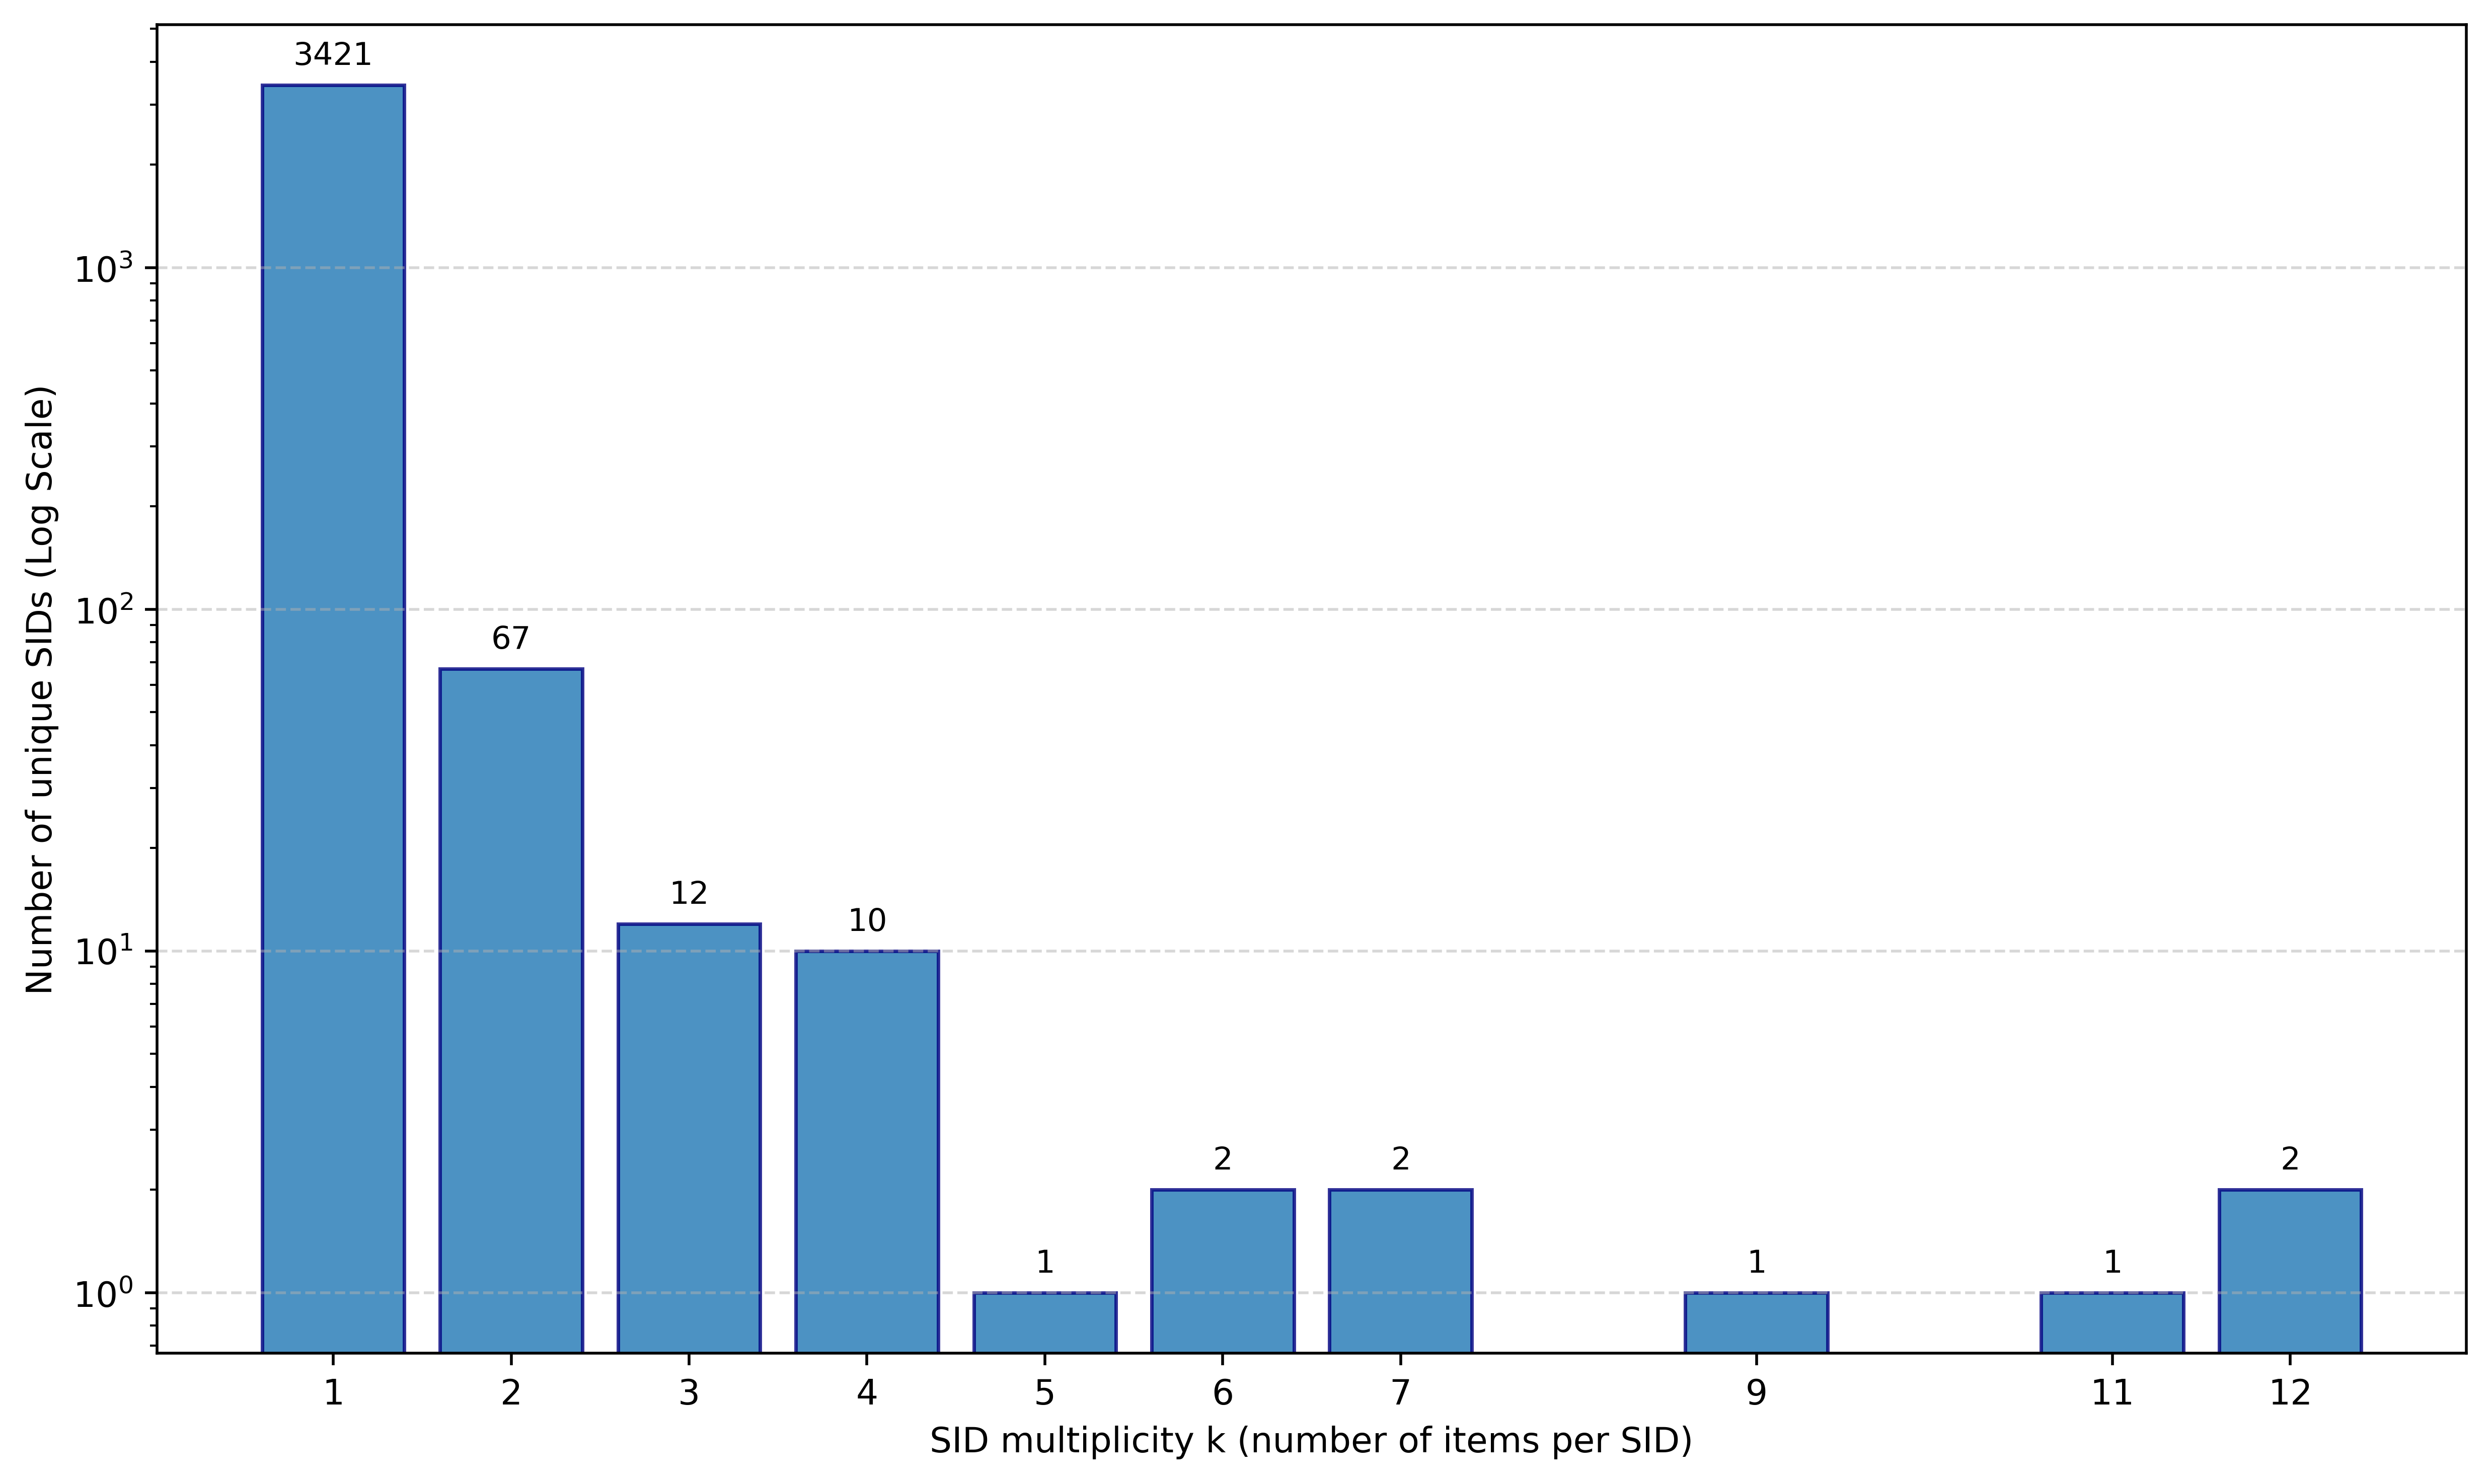

In [10]:
freq = np.array(sorted(d.keys()))
occ = np.array([d[f] for f in freq])

plt.figure(figsize=(10, 6), dpi=500)
plt.bar(freq, occ, edgecolor='navy', alpha=0.8)

plt.yscale('log')  

plt.xlabel('SID multiplicity k (number of items per SID)')
plt.ylabel('Number of unique SIDs (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(freq)

for x, y in zip(freq, occ):
        plt.text(x, y * 1.1, str(y), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### **The multiplicity distribution is heavily concentrated at 𝑘 = 1, while higher multiplicities form a long tail. This indicates that SID collisions are relatively rare. The log-scale axis is used to make low-frequency collision events visible.**

In [11]:
SIDs

array([[413, 105, 318, 205,  58],
       [992, 562, 104,  41,  29],
       [696, 839, 342,  16, 116],
       ...,
       [739, 419,  51,  31,  56],
       [230, 105,  74, 155,  90],
       [992, 419, 295, 151,  58]], dtype=int64)

In [12]:
sd[9]

[[739, 213, 51, 153, 51]]

In [13]:
sd[11]

[[739, 839, 51, 205, 53]]

In [14]:
sd[12]

[[739, 302, 51, 205, 53], [739, 839, 51, 205, 122]]

### Research for SID [739, 213, 51, 153, 51] (k = 9)

In [15]:
sid = sd[9][0]
indices = np.where(np.all(SIDs == sid, axis=1))
films.iloc[indices]

,movie_id,item_idx,title,years,genres
1703,1883,1703,Bulworth,1998,[Comedy]
2370,2567,2370,EDtv,1999,[Comedy]
2421,2623,2421,Trippin',1999,[Comedy]
2486,2690,2486,"Ideal Husband, An",1999,[Comedy]
2565,2770,2565,Bowfinger,1999,[Comedy]
3282,3515,3282,Me Myself I,2000,[Comedy]
3479,3721,3479,Trixie,1999,[Comedy]
3638,3884,3638,"Crew, The",2000,[Comedy]
3696,3943,3696,Bamboozled,2000,[Comedy]


### Research for SID [739, 839, 51, 205, 53] (k = 11)

In [16]:
sid = sd[11][0]
indices = np.where(np.all(SIDs == sid, axis=1))
films.iloc[indices]

,movie_id,item_idx,title,years,genres
994,1062,994,"Sunchaser, The",1996,[Drama]
1337,1442,1337,Prefontaine,1997,[Drama]
2047,2237,2047,Without Limits,1998,[Drama]
2113,2305,2113,Slam,1998,[Drama]
2165,2358,2165,Savior,1998,[Drama]
2299,2493,2299,"Harmonists, The",1997,[Drama]
2555,2760,2555,"Gambler, The",1997,[Drama]
2794,3006,2794,"Insider, The",1999,[Drama]
2899,3115,2899,Flawless,1999,[Drama]
2974,3192,2974,"Terrorist, The",1998,[Drama]


### Research for SID [739, 302, 51, 205, 53] (k = 12)

In [17]:
sid= sd[12][0]
indices = np.where(np.all(SIDs == sid, axis=1))
films.iloc[indices]

,movie_id,item_idx,title,years,genres
26,27,26,Now and Then,1995,[Drama]
195,201,195,Three Wishes,1995,[Drama]
213,219,213,"Cure, The",1995,[Drama]
275,282,275,Nell,1994,[Drama]
291,300,291,Quiz Show,1994,[Drama]
327,337,327,What's Eating Gilbert Grape,1993,[Drama]
348,358,348,Higher Learning,1995,[Drama]
442,456,442,Fresh,1994,[Drama]
735,778,735,Trainspotting,1996,[Drama]
926,989,926,Schlafes Bruder,1995,[Drama]


### Research for SID [739, 839, 51, 205, 122] (k = 12)

In [18]:
sid= sd[12][1]
indices = np.where(np.all(SIDs == sid, axis=1))
films.iloc[indices]

,movie_id,item_idx,title,years,genres
1268,1366,1268,"Crucible, The",1996,[Drama]
1448,1579,1448,For Ever Mozart,1996,[Drama]
1725,1905,1725,Marie Baie Des Anges,1997,[Drama]
2117,2309,2117,"Inheritors, The",1998,[Drama]
2143,2336,2143,Elizabeth,1998,[Drama]
2242,2435,2242,Hurlyburly,1998,[Drama]
2479,2682,2479,Limbo,1999,[Drama]
2703,2911,2703,"Grandfather, The",1998,[Drama]
2749,2960,2749,Beefcake,1999,[Drama]
2837,3051,2837,Anywhere But Here,1999,[Drama]


### **Qualitative inspection of high-multiplicity SID clusters reveals strong semantic coherence. Collision clusters are nearly genre-pure (e.g., all-comedy or all-drama groups) and exhibit narrow temporal spans (e.g., 1998–2000 for a comedy cluster). Moreover, several clusters share stable token patterns across specific SID positions (e.g., [739, x, 51, 205, x] for drama), suggesting that different SID positions encode different latent factors such as genre and release era**

In [19]:
def token_usage_entropy_norm(x, codebook_size: int) -> float:
    x = np.asarray(x).reshape(-1)
    N = x.size

    _, counts = np.unique(x, return_counts=True)
    p = counts / N  

    H = -(p * np.log(p)).sum()

    if codebook_size <= 1:
        return 0.0
    H_norm = H / np.log(codebook_size)
    return float(H_norm)
    
codebook_sizes = [2048, 1024, 512, 256, 128]

entropy_levels = []
for i, C in enumerate(codebook_sizes):
    entropy_levels.append(token_usage_entropy_norm(SIDs[:, i], codebook_size=C))

entropy_levels = np.array(entropy_levels)

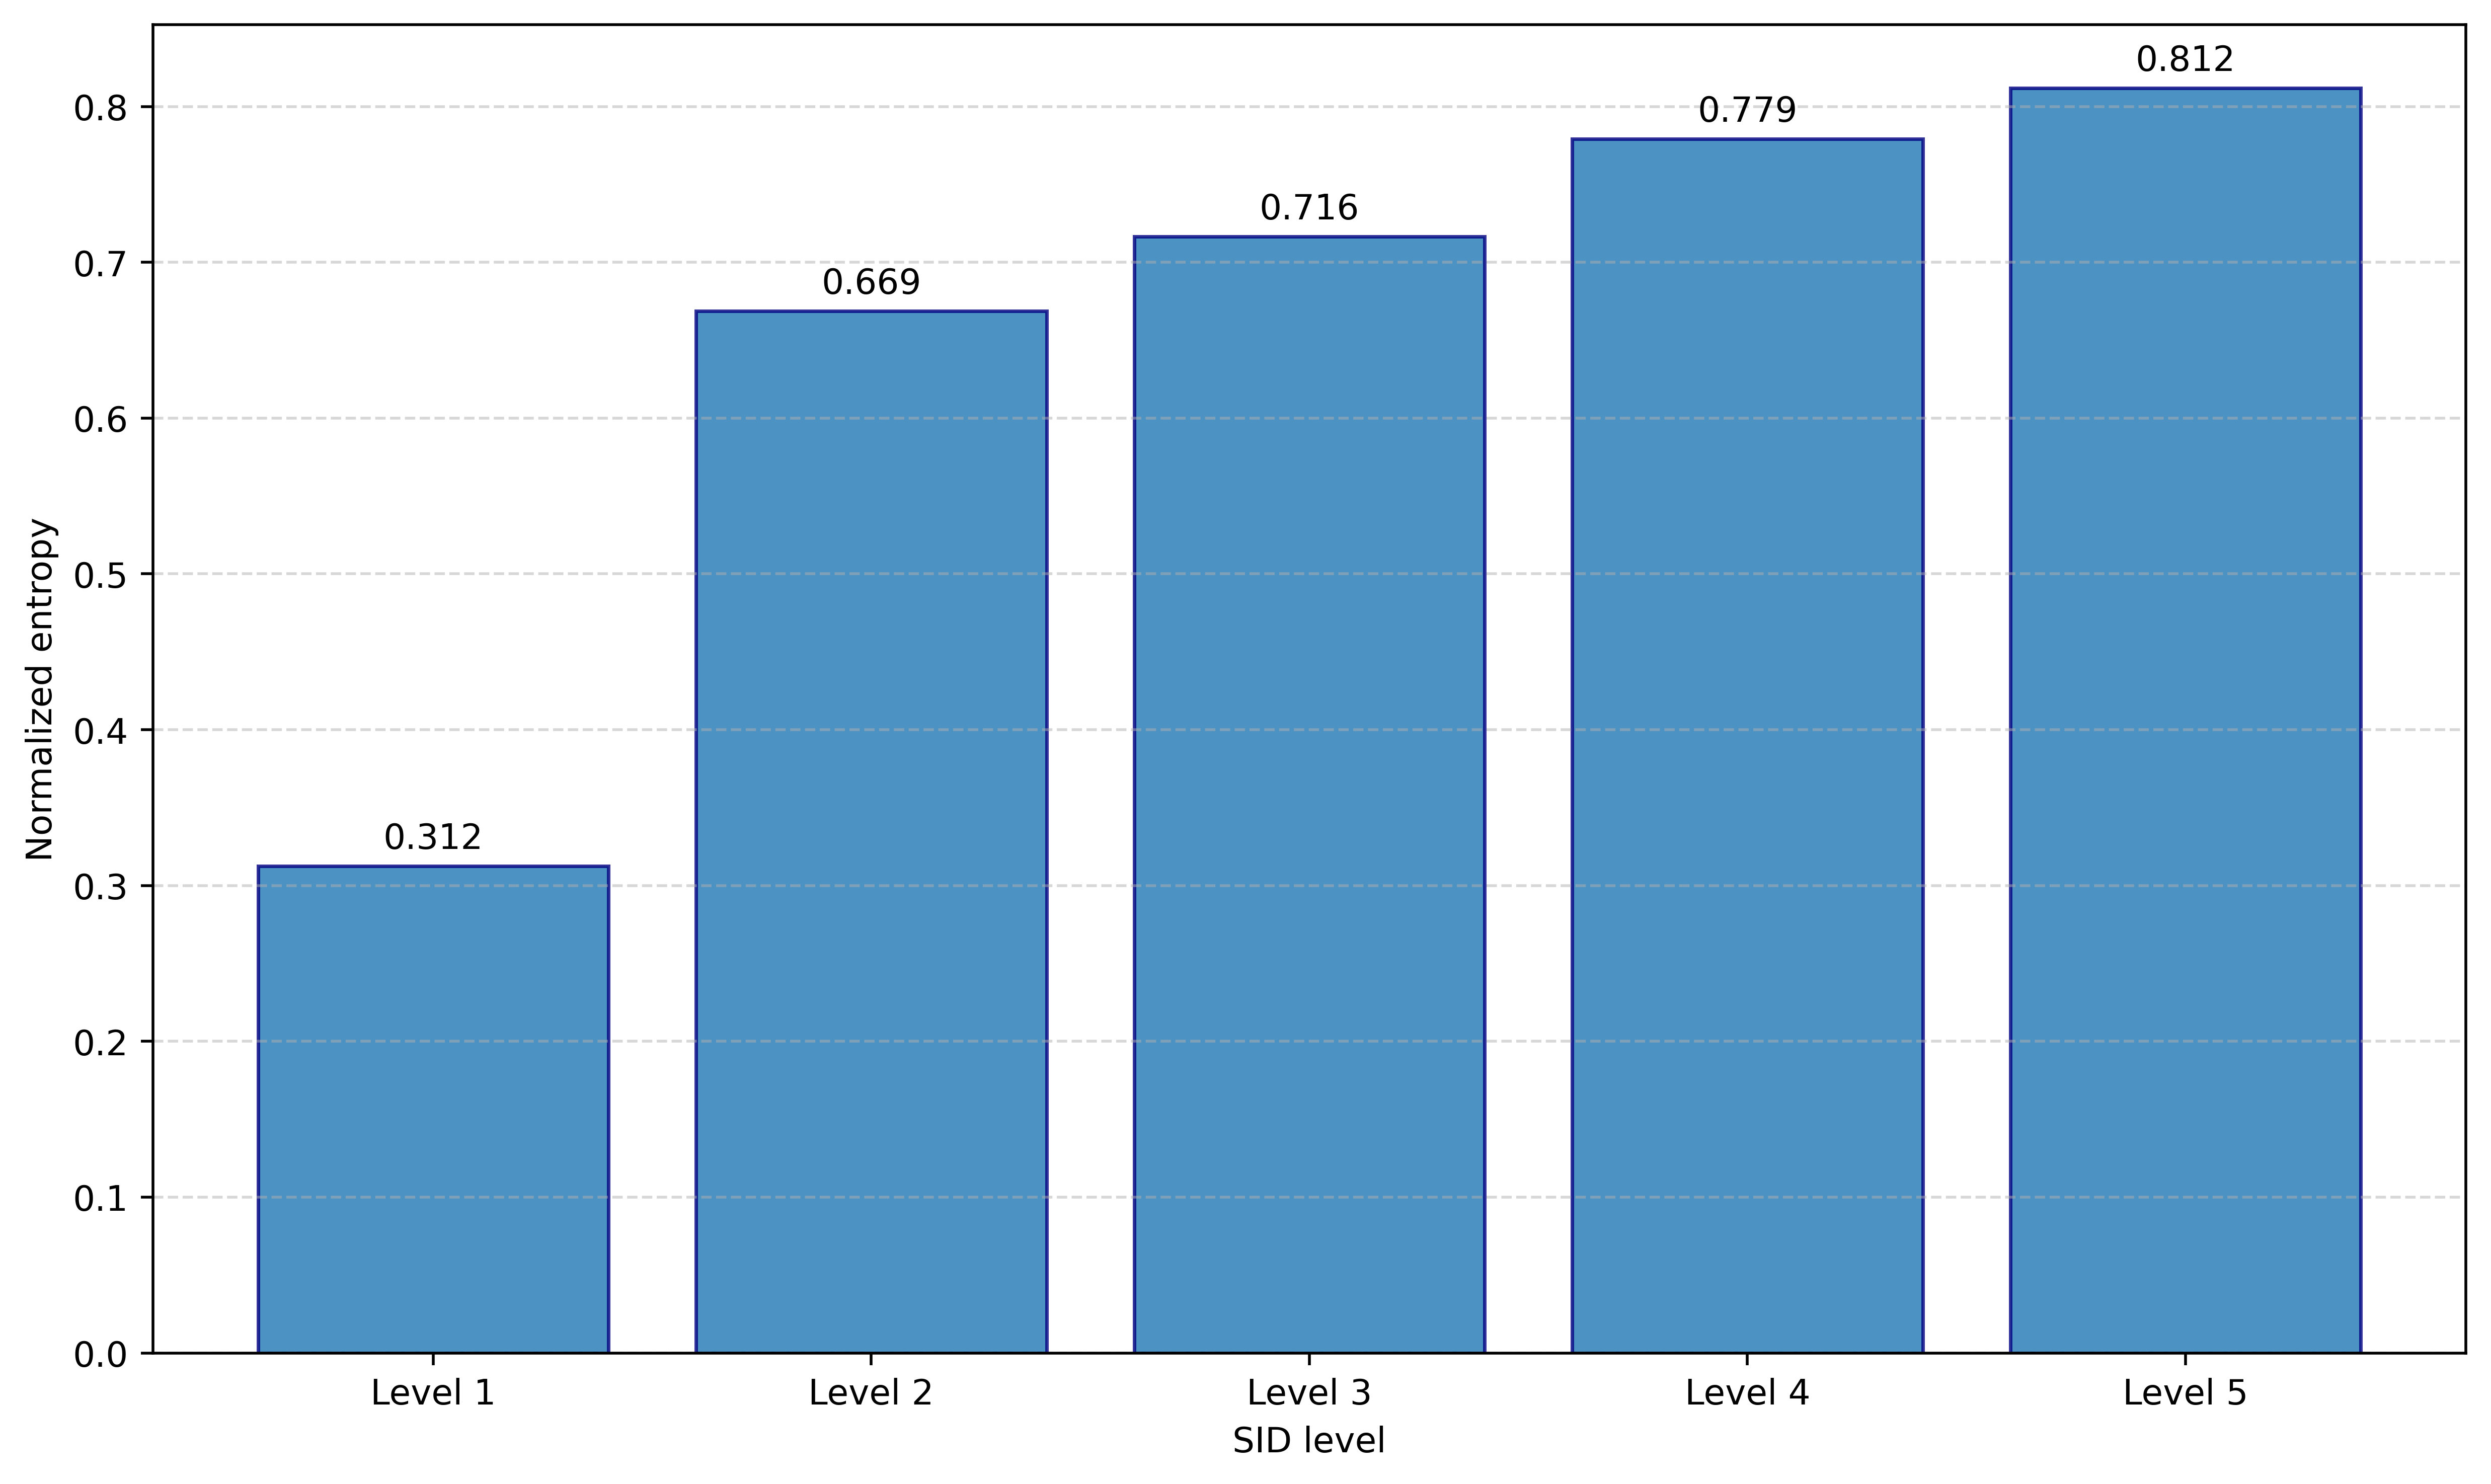

In [20]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=500)

bars = ax.bar(
    np.arange(1, 6),
    entropy_levels,
    edgecolor='navy',
    alpha=0.8
)

ax.set_xticks(np.arange(1, 6), [f"Level {i}" for i in range(1, 6)])
ax.set_xlabel("SID level")
ax.set_ylabel("Normalized entropy")
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar_label(bars, labels=[f"{v:.3f}" for v in entropy_levels], padding=3)

plt.tight_layout()
plt.show()


# !!! Codebook size [2048, 1024, 512, 256, 128]

In [8]:
data_path = '../data/processed/item_features/item_meta.parquet'
data = pd.read_parquet(data_path)

In [9]:
data.head()

,movie_id,item_idx,title,years,genres
0,1,0,Toy Story,1995,"[Animation, Children's, Comedy]"
1,2,1,Jumanji,1995,"[Adventure, Children's, Fantasy]"
2,3,2,Grumpier Old Men,1995,"[Comedy, Romance]"
3,4,3,Waiting to Exhale,1995,"[Comedy, Drama]"
4,5,4,Father of the Bride Part II,1995,[Comedy]


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3706 entries, 0 to 3705
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3706 non-null   int64 
 1   item_idx  3706 non-null   int32 
 2   title     3706 non-null   str   
 3   years     3706 non-null   Int64 
 4   genres    3706 non-null   object
dtypes: Int64(1), int32(1), int64(1), object(1), str(1)
memory usage: 194.9+ KB


In [11]:
mlb = MultiLabelBinarizer()

genres = mlb.fit_transform(data['genres'])
all_genres = list(mlb.classes_)

In [12]:
columns = ['level_0', 'level_1', 'level_2', 'level_3', 'level_4']
SIDs_df = pd.DataFrame(SIDs, columns=columns)
SIDs_df.head()

,level_0,level_1,level_2,level_3,level_4
0,413,105,318,205,58
1,992,562,104,41,29
2,696,839,342,16,116
3,405,419,485,5,79
4,992,105,448,31,120


In [13]:
len(all_genres)

18

In [14]:
for i in range(len(all_genres)):
    
    current_genre = all_genres[i]
    OHE = genres[:, i]

    SIDs_df[current_genre] = OHE

SIDs_df

,level_0,level_1,level_2,level_3,level_4,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,413,105,318,205,58,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,992,562,104,41,29,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,696,839,342,16,116,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,405,419,485,5,79,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,992,105,448,31,120,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,739,621,399,255,96,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3702,992,408,24,40,11,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3703,739,419,51,31,56,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3704,230,105,74,155,90,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
X = SIDs_df[columns].to_numpy()
y = SIDs_df[all_genres].to_numpy()

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=10)
train_val_idx, test_idx = next(msss.split(X, y))

X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]
X_test, y_test = X[test_idx], y[test_idx]

msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=10)
train_idx, val_idx = next(msss2.split(X_train_val, y_train_val))

X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
X_val, y_val     = X_train_val[val_idx], y_train_val[val_idx]

### Train + Val loop

In [52]:
def func(X_train, y_train, X_val, y_val) -> dict:

    cat_idx = [0, 1, 2, 3, 4]
    p_grid = np.linspace(0.05, 0.95, 30)
    
    per_genre_logs = {}
    P_val_all = np.zeros((X_val.shape[0], len(all_genres)))
    best_thresholds = np.zeros(len(all_genres))
    iteration_history = [0] * len(all_genres)
    
    for i in range(len(all_genres)):
    
        current_genre = all_genres[i]
        y_train_for_genre = y_train[:, i]
        y_val_for_genre = y_val[:, i]
        
        train_pool = Pool(X_train, y_train_for_genre, cat_features=cat_idx)
        val_pool =  Pool(X_val, y_val_for_genre, cat_features=cat_idx)
    
        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.015,
            depth=7,
            l2_leaf_reg=6,
            loss_function='Logloss',
            eval_metric='AUC',
            task_type='CPU',
            auto_class_weights='Balanced',
            verbose=0
        )
    
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=100)
        best_iter = model.get_best_iteration() + 1
        iteration_history[i] = best_iter

        p_val = model.predict_proba(X_val)[:, 1] 
        roc_auc = roc_auc_score(y_val_for_genre, p_val)
        pr_auc  = average_precision_score(y_val_for_genre, p_val)
        
        best_f1 = -1.0
        best_t = None
        best_prec = None
        best_rec = None
        
        for t in p_grid:
            y_hat = (p_val >= t).astype(int)
            f1 = f1_score(y_val_for_genre, y_hat, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
                best_prec = precision_score(y_val_for_genre, y_hat, zero_division=0)
                best_rec  = recall_score(y_val_for_genre, y_hat, zero_division=0)
        
        per_genre_logs[current_genre] = {
            'support_val': y_val_for_genre.sum(),
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'best_t': best_t,
            'best_f1': best_f1,
            'precision': best_prec,
            'recall': best_rec
        }
        P_val_all[:, i] = p_val
        best_thresholds[i] = best_t if best_t is not None else 0.5
    
    Y_hat_val = (P_val_all >= best_thresholds.reshape(1, -1)).astype(int)
    
    lrap = label_ranking_average_precision_score(y_val.astype(int), P_val_all)
    micro_f1 = f1_score(y_val.astype(int), Y_hat_val, average='micro', zero_division=0)
    macro_f1 = f1_score(y_val.astype(int), Y_hat_val, average='macro', zero_division=0)
    
    macro_pr_auc = float(np.mean([v['pr_auc'] for v in per_genre_logs.values() if v['pr_auc'] is not None]))
    macro_roc_auc = float(np.mean([v['roc_auc'] for v in per_genre_logs.values() if v['roc_auc'] is not None]))
    
    global_summary = {
        'LRAP': lrap,
        'micro_F1': micro_f1,
        'macro_F1': macro_f1,
        'macro_PR_AUC': macro_pr_auc,
        'macro_ROC_AUC': macro_roc_auc,
    }

    return global_summary, best_thresholds, iteration_history

### **We evaluate whether Semantic IDs encode genre information by training binary CatBoost probes (one per genre) using only the 5 SID tokens as features and reporting validation performance. As a control, we then shuffle X_train (keeping y_train fixed), retrain the probes, and compare results**

In [53]:
d1, best_thresholds, iteration_history = func(X_train, y_train, X_val, y_val)

### Let's shuffle X_train

In [54]:
X_train_shuffled = np.random.permutation(X_train)
d2, _,  _= func(X_train_shuffled, y_train, X_val, y_val)

In [55]:
results = pd.DataFrame([d1, d2], index=['Aligned', 'X_train_shuffled'])

In [56]:
results.head()

,LRAP,micro_F1,macro_F1,macro_PR_AUC,macro_ROC_AUC
Aligned,0.573800,0.282712,0.312339,0.298107,0.769279
X_train_shuffled,0.315854,0.189781,0.161293,0.112614,0.537354


### **When we destroy the item-level correspondence between SIDs and labels by shuffling X_train, all multilabel metrics drop sharply (LRAP 0.57→0.31, macro ROC-AUC 0.77→0.53). Since the marginal distributions of features and labels remain unchanged, this confirms that the original performance is driven by semantic information encoded in the SIDs rather than training artifacts**

In [57]:
best_thresholds

array([0.57758621, 0.57758621, 0.48448276, 0.48448276, 0.42241379,
       0.42241379, 0.73275862, 0.32931034, 0.51551724, 0.48448276,
       0.51551724, 0.54655172, 0.54655172, 0.57758621, 0.73275862,
       0.54655172, 0.48448276, 0.48448276])

In [63]:
cat_idx = [0, 1, 2, 3, 4]

per_genre_logs = dict()
p_test_all = np.zeros((X_test.shape[0], len(all_genres)))

for i in range(len(all_genres)):
    current_genre = all_genres[i]
    y_train_for_genre = y_train_val[:, i]

    train_pool = Pool(X_train_val, y_train_for_genre, cat_features=cat_idx)

    model = CatBoostClassifier(
                iterations=1000,
                learning_rate=0.015,
                depth=7,
                l2_leaf_reg=6,
                loss_function='Logloss',
                task_type='CPU',
                auto_class_weights='Balanced',
                verbose=0
            )

    model.fit(train_pool)
    p = model.predict_proba(X_test)[:, 1]
    p_test_all[:, i] = p
    pred = (p >= best_thresholds[i]).astype(int)
    
    roc_auc = roc_auc_score(y_test[:, i], p)
    pr_auc  = average_precision_score(y_test[:, i], p)
    f1 = f1_score(y_test[:, i], pred, zero_division=0)
    prec = precision_score(y_test[:, i], pred, zero_division=0)
    rec  = recall_score(y_test[:, i], pred, zero_division=0)
    
    per_genre_logs[current_genre] = {
            'support_test': y_test[:, i].sum(),
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'f1': f1,
            'precision': prec,
            'recall': rec
        }

y_hat_test = (p_test_all >= best_thresholds.reshape(1, -1)).astype(int)

lrap = label_ranking_average_precision_score(y_test.astype(int), p_test_all)
micro_f1 = f1_score(y_test.astype(int), y_hat_test, average='micro', zero_division=0)
macro_f1 = f1_score(y_test.astype(int), y_hat_test, average='macro', zero_division=0)

macro_pr_auc = float(np.mean([v['pr_auc'] for v in per_genre_logs.values() if v['pr_auc'] is not None]))
macro_roc_auc = float(np.mean([v['roc_auc'] for v in per_genre_logs.values() if v['roc_auc'] is not None]))

global_test = {
    'LRAP': lrap,
    'micro_F1': micro_f1,
    'macro_F1': macro_f1,
    'macro_PR_AUC': macro_pr_auc,
    'macro_ROC_AUC': macro_roc_auc
}

print(global_test)

{'LRAP': 0.6132794003866061, 'micro_F1': 0.48823529411764705, 'macro_F1': 0.25862149368596843, 'macro_PR_AUC': 0.2783728855280528, 'macro_ROC_AUC': 0.7269119718104619}


In [64]:
pd.DataFrame(global_test, index=['Test'])

,LRAP,micro_F1,macro_F1,macro_PR_AUC,macro_ROC_AUC
Test,0.613279,0.488235,0.258621,0.278373,0.726912


### **Previously, we showed that the learned Semantic IDs (SIDs) contain meaningful information by successfully predicting movie genres from SID tokens, and by a shuffle control where permuting X_train caused a sharp drop in performance. As an additional sanity check, we now test whether SIDs also capture temporal semantics by predicting the movie’s release year from the same SID representation. If SIDs truly encode semantic structure beyond genre-specific signals, they should allow a simple probe model to recover year-related information significantly better than chance, while the shuffled-feature control should again collapse performance**

In [77]:
data['years']

0       1995
1       1995
2       1995
3       1995
4       1995
        ... 
3701    2000
3702    2000
3703    2000
3704    2000
3705    2000
Name: years, Length: 3706, dtype: Int64

In [246]:
target_decades = data['years'].apply(lambda x: str(x)[:3] + '0s' if x >= 1970 else 'pre_1960s').reset_index()

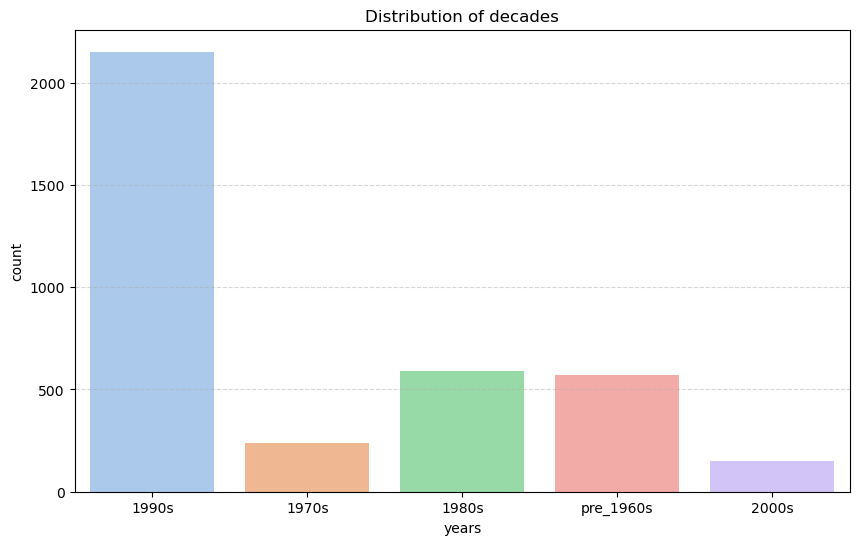

In [247]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of decades')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.countplot(data=target_decades, x='years', palette='pastel', hue='years')
plt.show()

In [248]:
X = SIDs_df[columns].to_numpy()
y = target_decades['years'].to_numpy()

In [260]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

In [261]:
decades = target_decades['years'].unique().to_numpy()
counts = target_decades['years'].value_counts()
weights = {decade: len(X) / (counts[decade] * len(y)) for decade in decades}

In [284]:
def func2(X_train, y_train, X_val, y_val) -> dict:
    cat_idx = [0, 1, 2, 3, 4]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_idx)
    val_pool   = Pool(X_val, y_val, cat_features=cat_idx)
    
    model = CatBoostClassifier(
        loss_function='MultiClass',
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=10,
        task_type='CPU',
        class_weights=weights,
        verbose=0
    )
    
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=200)
    y_pred = model.predict(X_val).reshape(-1)
    bal_acc = balanced_accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average='macro')

    d = {'balanced accuracy':bal_acc, 'f1 macro':macro_f1}
    return d

### **We also attempted to probe temporal semantics by training a multiclass classifier to predict a movie’s release decade from its SID tokens. Compared to the genre-prediction probe, the decade classification results were noticeably weaker, likely due to strong class imbalance (most items belong to the 1990s) and the fact that temporal information may be less directly represented in the learned SIDs. Nevertheless, to verify that the obtained performance is driven by real signal rather than artifacts, we run the same shuffle control as before: we permute only X_train (keeping y_train fixed), retrain the classifier, and compare validation metrics.**

In [285]:
d1 = func2(X_train, y_train, X_val, y_val)

### Let's shuffle X_train

In [288]:
rng = np.random.default_rng(42)

d2 = {'balanced accuracy':0, 'f1 macro':0}
n = 20
for _ in range(n):
    X_train_shuffled = rng.permutation(X_train)
    dt = func2(X_train_shuffled, y_train, X_val, y_val)
    d2['balanced accuracy'] += dt['balanced accuracy']
    d2['f1 macro'] += dt['f1 macro']
    
    
d2['balanced accuracy'] /= n
d2['f1 macro'] /= n

0.1409980033260047

In [290]:
d2['f1 macro'] /= n

In [291]:
pd.DataFrame([d1, d2], index=['Aligned', 'X_train shuffled'])

,balanced accuracy,f1 macro
Aligned,0.275519,0.211597
X_train shuffled,0.216274,0.140998


### **For decade prediction, the signal is weaker than for genres: however, it remains non-random. When we destroy the alignment between SIDs and labels by shuffling X_train and averaging over 20 permutations, performance drops from 0.275 to 0.216 in balanced accuracy and from 0.211 to 0.140 in macro-F1, indicating that SIDs still encode some temporal information. We additionally test whether Semantic IDs capture temporal information in a more fine-grained way by predicting the release year with a regression probe.**

In [15]:
X = SIDs_df[columns].to_numpy()
y = data['years'].to_numpy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

In [22]:
def func3(X_train, y_train, X_val, y_val) -> float:
    cat_idx = [0, 1, 2, 3, 4]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_idx)
    val_pool   = Pool(X_val, y_val, cat_features=cat_idx)
    
    model = CatBoostRegressor(
        loss_function='MAE',
        iterations=3000,
        learning_rate=0.03,
        depth=7,
        l2_leaf_reg=5,
        task_type='CPU',
        verbose=0
    )
    
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=200)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    return mae

In [23]:
mae = func3(X_train, y_train, X_val, y_val)

In [24]:
rng = np.random.default_rng(42)
shuffled_mae = 0

n = 10
for _ in range(n):
    X_train_shuffled = rng.permutation(X_train)
    shuffled_mae += func3(X_train_shuffled, y_train, X_val, y_val)
    
shuffled_mae /= n

In [31]:
median_baseline = np.median(y_train) * np.ones_like(y_val)
median_baseline_mae = mean_absolute_error(y_val, median_baseline)
pd.DataFrame(data={'MAE': [median_baseline_mae, shuffled_mae, mae]}, index=['Median baseline mae', 'X_train shuffled', 'Aligned']) 

,MAE
Median baseline mae,11.509275
X_train shuffled,11.484557
Aligned,11.144993


### **Exact release-year regression provides only marginal improvement over both the median baseline and shuffled control (≈0.35 MAE difference), suggesting that SIDs do not encode fine-grained temporal information. However, when predicting coarse temporal eras (decades with merged early classes), performance is consistently above shuffled baselines, indicating the presence of weak but non-zero temporal semantics**

In [36]:
np.save('../data/processed/SIDs_V1', SIDs)

In [34]:
SIDs

array([[413, 105, 318, 205,  58],
       [992, 562, 104,  41,  29],
       [696, 839, 342,  16, 116],
       ...,
       [739, 419,  51,  31,  56],
       [230, 105,  74, 155,  90],
       [992, 419, 295, 151,  58]], dtype=int64)